## Value: This converts raw data into an industry baseline to understand long-term creative output and publishing patterns.
----

### End-to-End Data Science Lifecycle: API Integration, Web Scraping, & EDA

## Project Overview
This notebook implements a complete, 6-stage Data Science and Data Engineering workflow. Instead of using static, pre-packaged files, this project builds automated pipelines to collect live data from the web, cleanses structural discrepancies, performs exploratory data analysis (EDA), and uncovers historical trends.

### The 6-Stage Workflow Framework:
1. Define the Problem: Set analytical goals to track a 50-year career trajectory (1974–2024).
2. Data Acquisition & Ingestion: Develop extraction pipelines for semi-structured API data and unstructured HTML markup.
3. Data Cleaning & Preprocessing: Flatten nested JSON objects, correct corrupted data types, and enforce data integrity.
4. Exploratory Data Analysis (EDA): Conduct statistical profiles, feature engineering, and outlier detection.
5. Data Visualization: Build descriptive charts tracking velocity, volume trends, and corporate publisher dominance.
6. Interpretation & Insights: Draw final analytical conclusions from data patterns.

---
## 🛠️ Environment Setup & Tech Stack
* Language: Python 3
* Libraries Used: requests, pandas, BeautifulSoup (bs4), lxml, matplotlib, seaborn
* Data Pipelines: REST API Consumption, DOM Tree Parsing, Local Data Staging/Caching

---


Dataset Name: Stephen King 50-Year Bibliography Dataset //
Author: Priyanshu Vijay //
Created: June 2026 //
Version: 1.0.0

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

# Data Acquisition

In [3]:
!pip install requests


In [4]:
url="https://stephen-king-api.onrender.com/api/books"

res = requests.get(url)

In [5]:
res # status code = 200 ~ ok 

<Response [200]>

## raw data of the books

In [6]:
data= res.json()
data

{'data': [{'id': 1,
   'Year': 1974,
   'Title': 'Carrie',
   'handle': 'carrie',
   'Publisher': 'Doubleday',
   'ISBN': '978-0-385-08695-0',
   'Pages': 199,
   'Notes': [''],
   'created_at': '2023-11-13T23:48:47.848Z',
   'villains': [{'name': 'Tina Blake',
     'url': 'https://stephen-king-api.onrender.com/api/villain/4'},
    {'name': 'Cindi',
     'url': 'https://stephen-king-api.onrender.com/api/villain/14'},
    {'name': 'Myra Crewes',
     'url': 'https://stephen-king-api.onrender.com/api/villain/16'},
    {'name': 'Billy deLois',
     'url': 'https://stephen-king-api.onrender.com/api/villain/25'},
    {'name': 'Kenny Garson',
     'url': 'https://stephen-king-api.onrender.com/api/villain/38'},
    {'name': 'Mary Lila Grace',
     'url': 'https://stephen-king-api.onrender.com/api/villain/44'},
    {'name': 'Christine Hargensen',
     'url': 'https://stephen-king-api.onrender.com/api/villain/49'},
    {'name': 'Vic Mooney',
     'url': 'https://stephen-king-api.onrender.com/ap

## collect data to file formate

In [7]:
import pandas as pd
df=pd.DataFrame(data)

In [8]:
df.to_json("retrieve_data.json")

## testing dataframe

In [ ]:
# filter on some basis

df= df[['id','Title','Year','ISBN']]

In [11]:
df.head(5)

,data
0,"{'id': 1, 'Year': 1974, 'Title': 'Carrie', 'ha..."
1,"{'id': 2, 'Year': 1975, 'Title': 'Salem's Lot'..."
2,"{'id': 3, 'Year': 1977, 'Title': 'The Shining'..."
3,"{'id': 4, 'Year': 1977, 'Title': 'Rage', 'hand..."
4,"{'id': 5, 'Year': 1978, 'Title': 'The Stand', ..."


## Importing the scrapper

In [12]:
# scrapping data to html (data1)

with open("scraped_data/data1.html","w", encoding="utf-8") as f:
   f.write(res.text)

In [15]:
# introducing the real scrapper for soup content lxlm

from bs4 import BeautifulSoup
with open("scraped_data/data1.html","r",encoding="utf-8") as f:
   content = f.read()
soup = BeautifulSoup(content,"lxml")
# soup

In [17]:
# extracted name of country and population from raw data

# beautifulSoup Methods

soup.find("h1")  # first occurance of h1
soup.find("h3")   # first occurance of h3

all_h3 = soup.find_all("h3")  # find all h3 info. together


all_countries=[]

for h3 in all_h3:
    name=h3.get_text(strip=True) # country  name
    
    # print(h3.find_parent("div")["class"])  # to find parent class
    
    # print(h3.find_next("div").select_one("span.country-population").get_text(strip=True))
    
    population=h3.find_next("div").select("span.country-population")[0].get_text(strip=True)
    all_countries.append([name,population])
    
    # print(all_countries)   ( we will have all the population details with country name)

In [23]:
print(type(all_h3))    # <class 'bs4.element.ResultSet'>

<class 'bs4.element.ResultSet'>


# Data preprocessing

## flattening .json data

In [24]:
#Nornalizing retrived data

df=pd.json_normalize(data["data"])
df

,id,Year,Title,handle,Publisher,ISBN,Pages,Notes,created_at,villains
0,1,1974,Carrie,carrie,Doubleday,978-0-385-08695-0,199,[],2023-11-13T23:48:47.848Z,"[{'name': 'Tina Blake', 'url': 'https://stephe..."
1,2,1975,Salem's Lot,salem-s-lot,Doubleday,978-0-385-00751-1,439,"[Nominee, World Fantasy Award, 1976[2]]",2023-11-13T23:48:48.098Z,"[{'name': 'Kurt Barlow', 'url': 'https://steph..."
2,3,1977,The Shining,the-shining,Doubleday,978-0-385-12167-5,447,"[Runner-up (4th place), Locus Award for Best F...",2023-11-13T23:48:48.219Z,"[{'name': 'Horace M. Derwent', 'url': 'https:/..."
3,4,1977,Rage,rage,Signet Books,978-0-451-07645-8,211,[Published under pseudonym Richard Bachman],2023-11-13T23:48:48.339Z,[]
4,5,1978,The Stand,the-stand,Doubleday,978-0-385-12168-2,823,"[Nominee, World Fantasy Award, 1979, Runner-up...",2023-11-13T23:48:48.477Z,"[{'name': 'Donald Merwin Elbert', 'url': 'http..."
...,...,...,...,...,...,...,...,...,...,...
58,59,2018,The Outsider,the-outsider,Scribner,978-1-50118-098-9,576,"[First novel in the Holly Gibney Series, Runne...",2023-11-13T23:48:55.165Z,"[{'name': 'The Outsider (Creature)', 'url': 'h..."
59,60,2018,Elevation,elevation,Scribner,978-1-98210-231-9,144,[],2023-11-13T23:48:55.291Z,[]
60,61,2019,The Institute,the-institute,Scribner,978-1-98211-056-7,576,"[Nominee, British Fantasy Award's August Derle...",2023-11-13T23:48:55.457Z,"[{'name': 'Gladys Hickson', 'url': 'https://st..."
61,62,2021,Later,later,Hard Case Crime,978-1-78909-649-1,256,[],2023-11-13T23:48:55.579Z,[]


In [25]:
# Check basic information about data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          63 non-null     int64 
 1   Year        63 non-null     int64 
 2   Title       63 non-null     object
 3   handle      63 non-null     object
 4   Publisher   63 non-null     object
 5   ISBN        63 non-null     object
 6   Pages       63 non-null     int64 
 7   Notes       63 non-null     object
 8   created_at  63 non-null     object
 9   villains    63 non-null     object
dtypes: int64(3), object(7)
memory usage: 5.1+ KB


In [26]:
# Get a quick statistical summary of numerical columns (like Pages and Year)
df.describe()

,id,Year,Pages
count,63.000000,63.000000,63.000000
mean,32.000000,1996.888889,480.349206
std,18.330303,13.993214,231.642324
min,1.000000,1974.000000,127.000000
25%,16.500000,1984.000000,314.500000
50%,32.000000,1996.000000,432.000000
75%,47.500000,2008.500000,591.500000
max,63.000000,2021.000000,1152.000000


## handle data type

In [27]:
# Convert 'Pages' and 'Year' to integers, forcing errors to 'NaN' if there's text corruption

df['Pages'] = pd.to_numeric(df['Pages'], errors='coerce').fillna(0).astype(int)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(0).astype(int)

# Check if data types are now correct (should show int32 or int64)
print(df[['Pages', 'Year']].dtypes)

Pages    int64
Year     int64
dtype: object


## Data Integrity Checks

In [28]:
# Check for missing values across all columns
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 id            0
Year          0
Title         0
handle        0
Publisher     0
ISBN          0
Pages         0
Notes         0
created_at    0
villains      0
dtype: int64


In [29]:
# Check for and remove duplicate books based on a unique identifier

duplicate_count = df.duplicated(subset=['id']).sum()
print(f"Found {duplicate_count} duplicate rows.")


Found 0 duplicate rows.


# EDA exploratory data anlysis
Analyze the clean data using descriptive statistics and visualizations to discover trends, patterns, and anomalies that answer your core questions.

## statical anlysis

In [30]:
# Numerical columns 

print(df[['Pages', 'Year']].describe())

# Categorical columns 
print(df[['Publisher', 'Title']].describe(include='object'))

             Pages         Year
count    63.000000    63.000000
mean    480.349206  1996.888889
std     231.642324    13.993214
min     127.000000  1974.000000
25%     314.500000  1984.000000
50%     432.000000  1996.000000
75%     591.500000  2008.500000
max    1152.000000  2021.000000
       Publisher   Title
count         63      63
unique        15      63
top     Scribner  Carrie
freq          20       1


## Visual Distribution

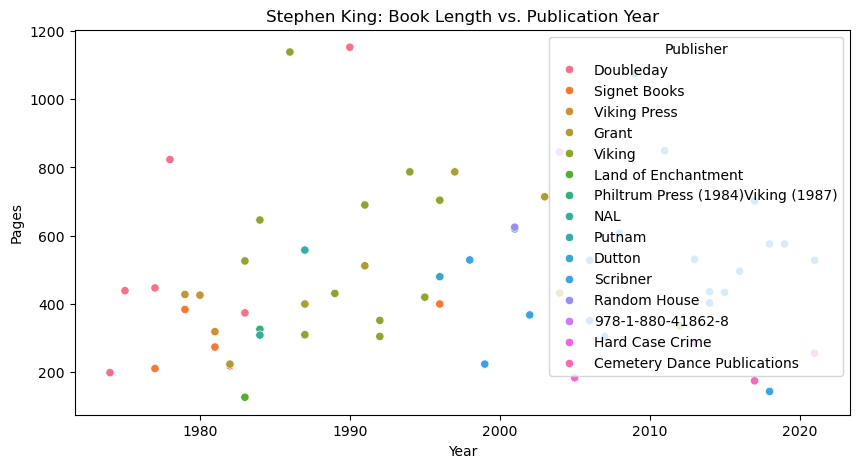

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot book length over time to see if his books are getting longer
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Year', y='Pages', hue='Publisher')
plt.title('Stephen King: Book Length vs. Publication Year')
plt.savefig(
    'Extracted-graphs/book_length_evolution.png', 
    dpi=300, 
    facecolor='white', 
    bbox_inches='tight'
)
plt.show()

## Categorical Aggregation
Identify which stakeholders dominate the dataset.

In [32]:
# Count how many books each publisher has  released

publisher_counts = df['Publisher'].value_counts()
print(publisher_counts)

Publisher
Scribner                              20
Viking                                11
Grant                                  7
Doubleday                              6
Signet Books                           5
Viking Press                           3
Hard Case Crime                        3
Land of Enchantment                    1
Philtrum Press (1984)Viking (1987)     1
NAL                                    1
Putnam                                 1
Dutton                                 1
Random House                           1
978-1-880-41862-8                      1
Cemetery Dance Publications            1
Name: count, dtype: int64


# Feature Engineering

In [33]:
# Decade' column (e.g., 1974 becomes 1970s)

df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'

# Now count books published per decade


print(df['Decade'].value_counts().sort_index())

Decade
1970s     7
1980s    16
1990s    13
2000s    12
2010s    13
2020s     2
Name: count, dtype: int64


## outlier detection

In [34]:
# Finding  the rows with the absolute maximum and minimum numbres of pages

longest_book = df.loc[df['Pages'].idxmax()]
shortest_book = df.loc[df['Pages'].idxmin()]

print(f"Longest Book: {longest_book['Title']} ({longest_book['Pages']} pages)")
print(f"Shortest Book: {shortest_book['Title']} ({shortest_book['Pages']} pages)")

Longest Book: The Stand Uncut (1152 pages)
Shortest Book: Cycle of the Werewolf (127 pages)


## mining for most used words in stephen king's book

In [35]:
# Combine all titles and find the most common words

from collections import Counter

all_titles_text = " ".join(df['Title']).lower()
words = [word for word in all_titles_text.split() if len(word) > 3] # skip short words like 'the', 'of'
common_words = Counter(words).most_common(5)

print("Most common words in Stephen King titles:", common_words)

Most common words in Stephen King titles: [('dark', 10), ('tower', 7), ('stand', 2), ('tower:', 2), ('carrie', 1)]


# Data Visualization
Transform the raw statistical insights into clean, visual narratives that anybody can understand at a glance.

## The Volume Story (Career Productivity)

This chart tracks how consistent his output has been year-by-year, helping you spot highly prolific creative eras versus publication lulls.

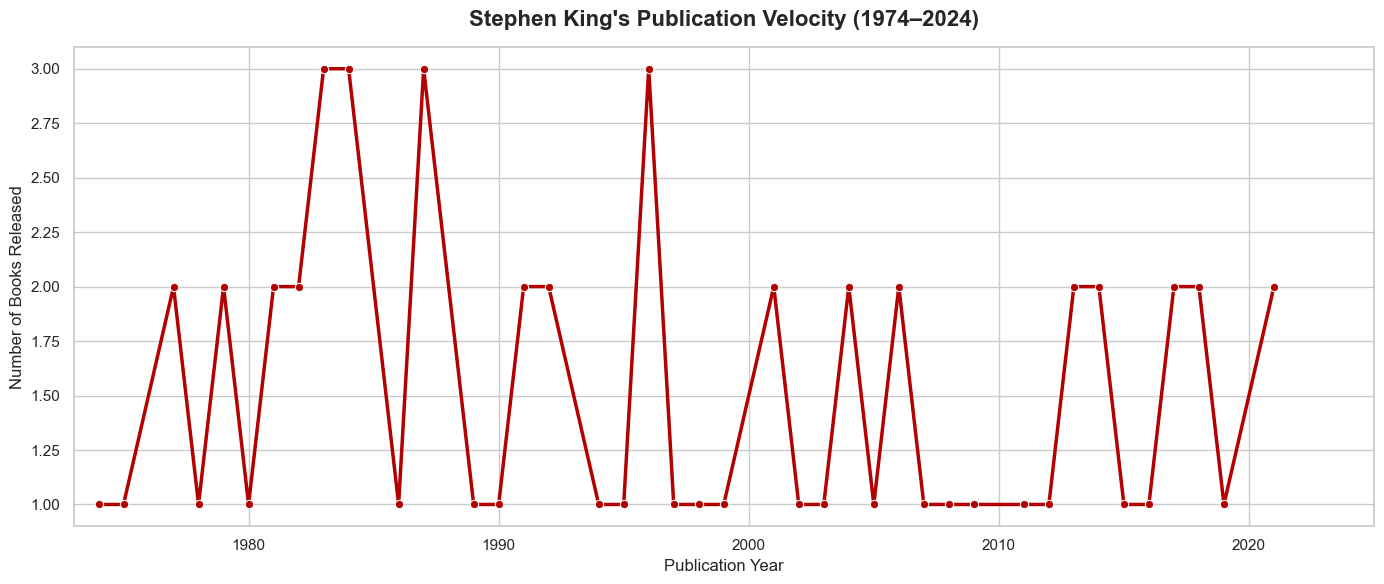

In [36]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# annual book counts

yearly_counts = df['Year'].value_counts().sort_index()

#  Line Plot


sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker="o", color="#b30000", linewidth=2.5)

plt.title("Stephen King's Publication Velocity (1974–2024)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Publication Year", fontsize=12)
plt.ylabel("Number of Books Released", fontsize=12)
plt.xlim(1973, 2025)
plt.tight_layout()
plt.savefig(
    'Extracted-graphs/stephen_productivity.png', 
    dpi=300, 
    facecolor='white', 
    bbox_inches='tight'
)
plt.show()

## Evolution of Book Length
This chart displays individual books as points to visually prove whether Stephen King started writing significantly longer

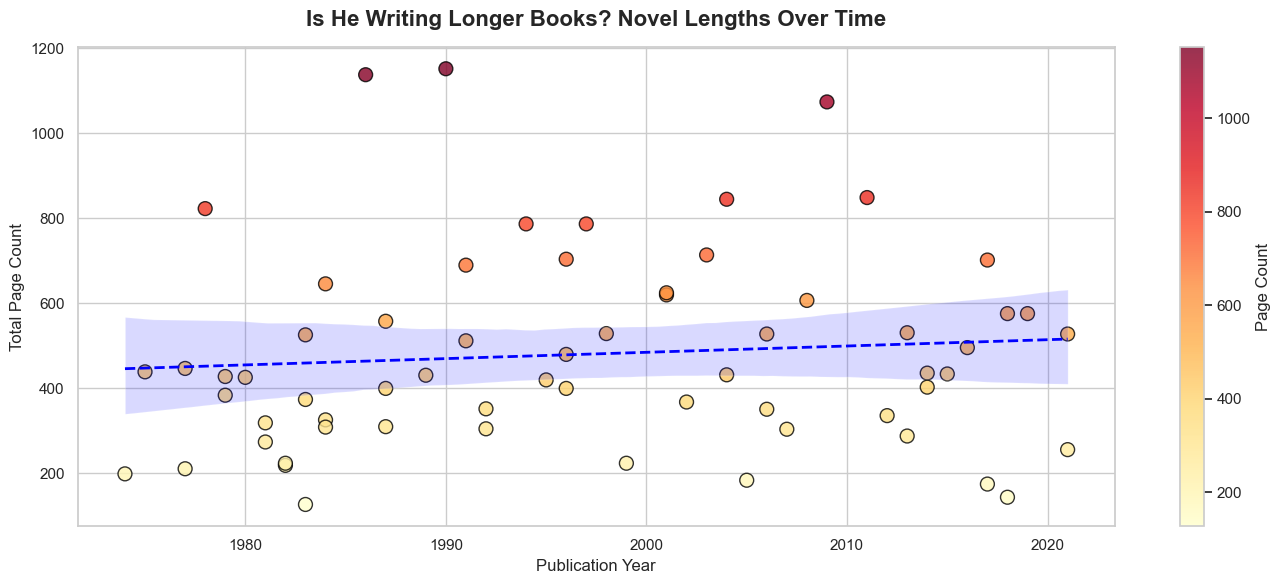

In [37]:
plt.figure(figsize=(14, 6))

# Generate scatter plot 
scatter = plt.scatter(data=df, x='Year', y='Pages', c='Pages', cmap='YlOrRd', edgecolor='black', alpha=0.8, s=100)

# Statistical trend line (Regression Line) =  long-term trajectory

sns.regplot(data=df, x='Year', y='Pages', scatter=False, color="blue", line_kws={"linestyle": "--", "linewidth": 2})


plt.colorbar(scatter, label="Page Count")
plt.title("Is He Writing Longer Books? Novel Lengths Over Time", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Publication Year", fontsize=12)
plt.ylabel("Total Page Count", fontsize=12)
plt.tight_layout()
plt.savefig(
    'Extracted-graphs/evaluation_of_length.png', 
    dpi=300, 
    facecolor='white', 
    bbox_inches='tight'
)
plt.show()

## Publisher Market Share
This isolates his business ecosystem. It cleanly ranks his primary publishers so the audience can instantly spot who holds the dominant market share of his bibliography.

C:\Users\HP\AppData\Local\Temp\ipykernel_13744\1450678368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="viridis", edgecolor='black')


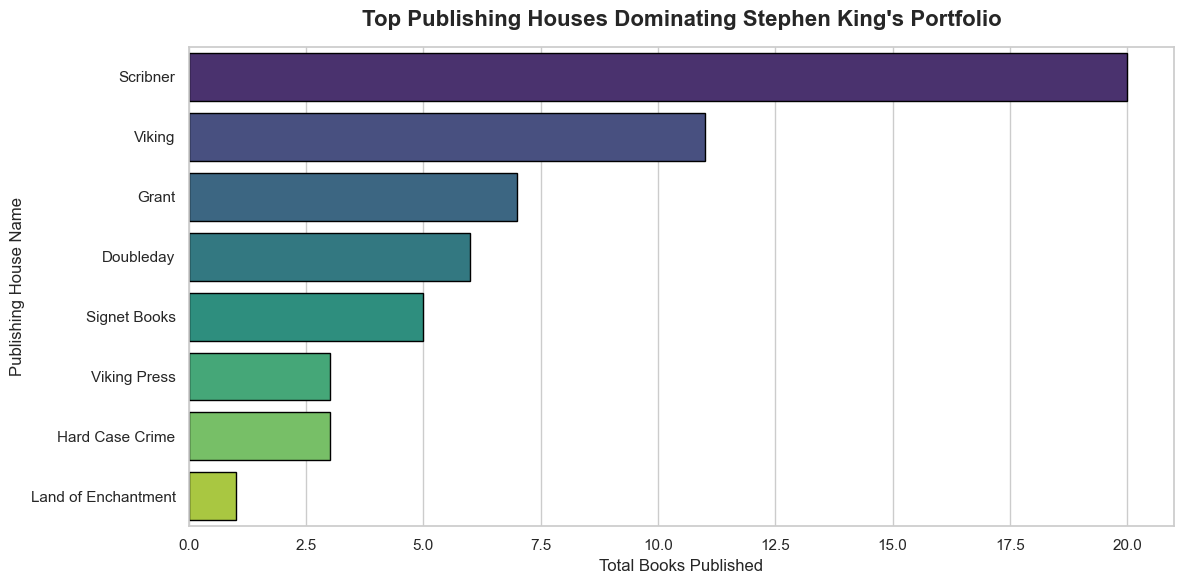

In [38]:
plt.figure(figsize=(12, 6))

#  top publishers
top_publishers = df['Publisher'].value_counts().head(8)

# horizontal bar chart
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="viridis", edgecolor='black')

plt.title("Top Publishing Houses Dominating Stephen King's Portfolio", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Total Books Published", fontsize=12)
plt.ylabel("Publishing House Name", fontsize=12)
plt.tight_layout()
plt.savefig(
    'Extracted-graphs/market_share_of_publishers.png', 
    dpi=300, 
    facecolor='white', 
    bbox_inches='tight'
)
plt.show()

# Insights

In [39]:
# A. Get exact career boundaries
start_year = df['Year'].min()
end_year = df['Year'].max()
total_books = len(df)

# B. Calculate productivity rate (Average books per year active)
years_active = (end_year - start_year) + 1
books_per_year = total_books / years_active

# C. Get exact stats on his most dominant publisher
top_pub = df['Publisher'].value_counts().index[0]
top_pub_count = df['Publisher'].value_counts().values[0]
top_pub_percentage = (top_pub_count / total_books) * 100

print(f"Career Span: {start_year} to {end_year} ({years_active} years)")
print(f"Productivity Velocity: {books_per_year:.2f} books/year")
print(f"Dominant Publisher: {top_pub} ({top_pub_count} books, {top_pub_percentage:.1f}%)")

Career Span: 1974 to 2021 (48 years)
Productivity Velocity: 1.31 books/year
Dominant Publisher: Scribner (20 books, 31.7%)


# Machine Learning pipeline

[ Raw Features ] ➡️ [ 1. Encoding Logic ] ➡️ [ 2. Matrix Splitting ] ➡️ [ 3. Ensemble Training ] ➡️ [ 4. Optimization & Evaluation ]

## Feature Transformation (Encoding Logic)

In [40]:
print(df.columns.tolist())
print(df.head(2))

['id', 'Year', 'Title', 'handle', 'Publisher', 'ISBN', 'Pages', 'Notes', 'created_at', 'villains', 'Decade']
   id  Year        Title       handle  Publisher               ISBN  Pages  \
0   1  1974       Carrie       carrie  Doubleday  978-0-385-08695-0    199   
1   2  1975  Salem's Lot  salem-s-lot  Doubleday  978-0-385-00751-1    439   

                                     Notes                created_at  \
0                                       []  2023-11-13T23:48:47.848Z   
1  [Nominee, World Fantasy Award, 1976[2]]  2023-11-13T23:48:48.098Z   

                                            villains Decade  
0  [{'name': 'Tina Blake', 'url': 'https://stephe...  1970s  
1  [{'name': 'Kurt Barlow', 'url': 'https://steph...  1970s  


In [41]:
import pandas as pd

# read the raw json file
raw_df = pd.read_json('retrieve_data.json')

# extract and flatten the nested dictionary objects inside the 'data' column

df = pd.json_normalize(raw_df['data'])

## double check
print("✅ New Expanded Columns:", df.columns.tolist())

✅ New Expanded Columns: ['id', 'Year', 'Title', 'handle', 'Publisher', 'ISBN', 'Pages', 'Notes', 'created_at', 'villains']


In [42]:
# defining target

y = df['Pages']

# defining features
features = df[['Year', 'Publisher']]

# encoding logic
X = pd.get_dummies(features, columns=['Publisher'], drop_first=True)

print("🚀 ML-Ready Matrix Shape:", X.shape)
print(X.head(3))

🚀 ML-Ready Matrix Shape: (63, 15)
   Year  Publisher_Cemetery Dance Publications  Publisher_Doubleday  \
0  1974                                  False                 True   
1  1975                                  False                 True   
2  1977                                  False                 True   

   Publisher_Dutton  Publisher_Grant  Publisher_Hard Case Crime  \
0             False            False                      False   
1             False            False                      False   
2             False            False                      False   

   Publisher_Land of Enchantment  Publisher_NAL  \
0                          False          False   
1                          False          False   
2                          False          False   

   Publisher_Philtrum Press (1984)Viking (1987)  Publisher_Putnam  \
0                                         False             False   
1                                         False             False   


## Data Splitting Matrix
### Training and Testing data using (sklearn model)
We cannot train a machine learning model on our entire dataset and then test it on that exact same dataset. If we do, the model will just memorize the answers (overfitting), and we won't actually know if its predictions are accurate or if it just has a good memory.

We will use scikit-learn to automatically slice your data:

X_train & y_train ($80\%$): The textbooks. The model looks at these features and labels to learn patterns (e.g., "Books from publisher X in decade Y tend to be long").

X_test & y_test ($20\%$): The exam. The model is blind to this data during training. We use it later to grade how smart our model actually is.

In [43]:
from sklearn.model_selection import train_test_split

## split the data: 80% for training, 20% for testing

#  test random_state=42 to make sure the split is exactly the same every time we run it

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🏋️ Training Features Shape (80%):", X_train.shape)
print("📝 Testing Features Shape (20%):", X_test.shape)
print("🎯 Training Targets Shape:", y_train.shape)
print("🎯 Testing Targets Shape:", y_test.shape)

🏋️ Training Features Shape (80%): (50, 15)
📝 Testing Features Shape (20%): (13, 15)
🎯 Training Targets Shape: (50,)
🎯 Testing Targets Shape: (13,)


## Ensemble : Training the model
### Used Random Forest Regressor

In [44]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

# train the model using the training matrix 

print(" Training the Random Forest model on historical data...")

 Training the Random Forest model on historical data...


In [45]:
model.fit(X_train, y_train)
print("🎉 Model training complete!")

🎉 Model training complete!


In [46]:
# use the trained model to make predictions on the blind test exam

y_pred = model.predict(X_test)
print(" Predictions generated for the testing dataset.")

 Predictions generated for the testing dataset.


In [48]:
# predictions vs reality

comparison_df = pd.DataFrame({'Actual Pages': y_test, 'Predicted Pages': y_pred.round(1)})
print("\n Sample of Predictions vs Actual Values:")
print(comparison_df.head(5))


 Sample of Predictions vs Actual Values:
    Actual Pages  Predicted Pages
61           256            323.8
57           702            356.8
0            199            486.4
43           351            481.7
5            384            285.8


### All set we have extracted relavent info. & visuals from notebook, next we have to ::

1. train the model (train_model.py)
2. make a predictive model (predict.py)
3. add pipeline file (pipeline.py)